# Exploratory Data Analysis of Unemployment in India

## CodeAlpha Data Analytics Internship — Task 2

### Objective
The objective of this project is to explore unemployment data in India,
identify important trends and patterns, detect potential anomalies, and
generate meaningful insights using Python and data visualization.

## 1. Introduction

Exploratory Data Analysis (EDA) is the process of examining and understanding
a dataset using statistical methods and visualizations.

In this project, the Unemployment in India dataset is analyzed to understand
unemployment patterns across different regions, areas, and time periods.

The analysis focuses on unemployment rate, employment, labour participation,
regional differences, and Rural vs Urban areas.

## 2. Questions for Analysis

The following questions will be explored:

1. What is the overall distribution of unemployment rates?
2. How does the unemployment rate change over time?
3. Which regions have the highest and lowest average unemployment rates?
4. How does unemployment differ between Rural and Urban areas?
5. Is there a relationship between unemployment and labour participation?
6. Are there potential outliers or unusual observations in the dataset?
7. What relationships exist among the numerical variables?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Unemployment in India.csv")

df.head()
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.describe()
df.columns = df.columns.str.strip()

df.columns
df.isnull().sum()
df[df.isnull().any(axis=1)]
df = df.dropna()

print("Rows after cleaning:", df.shape[0])
df.duplicated().sum()
df = df.drop_duplicates()
print("Duplicates:", df.duplicated().sum())
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes
print("Average Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].mean())

print("Maximum Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].max())

print("Minimum Unemployment Rate:",
      df['Estimated Unemployment Rate (%)'].min())
df['Region'].unique()
df['Area'].value_counts()

Rows: 768
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
Rows after cleaning: 740
Duplicates: 0
Average Unemployment Rate: 11.787945945945946
Maximum Unemployment Rate: 76.74
Minimum Unemployment Rate: 0.0


,count
Area,
Urban,381
Rural,359


### 1 Distribution of Unemployment Rate

A histogram is used to understand the distribution of unemployment rates
and identify whether the data is concentrated in a particular range or
contains potential extreme values.

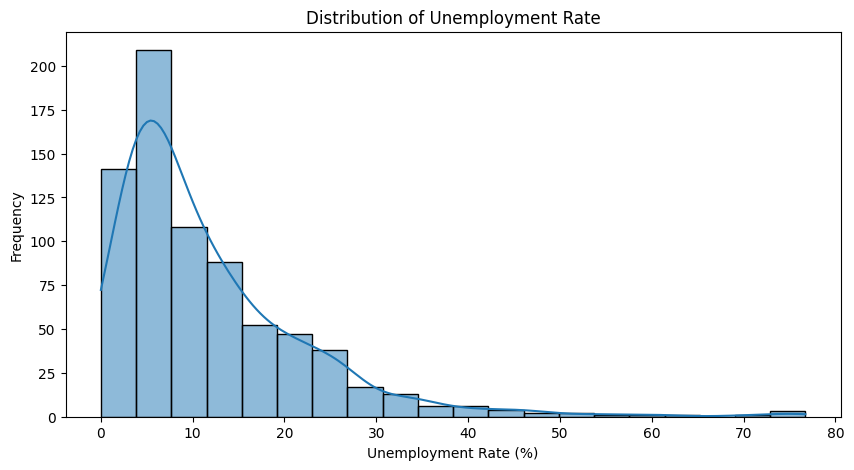

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')

plt.show()

### Insight

The unemployment rate distribution is positively skewed. Most observations
are concentrated at relatively lower unemployment rates, while a smaller
number of observations have much higher values, creating a long right tail.
These extreme observations should be examined as potential outliers.

## 2 Time-Based Analysis

###  Average Unemployment Rate Over Time

The average unemployment rate is calculated for each date to identify
overall changes and trends over the observed period.

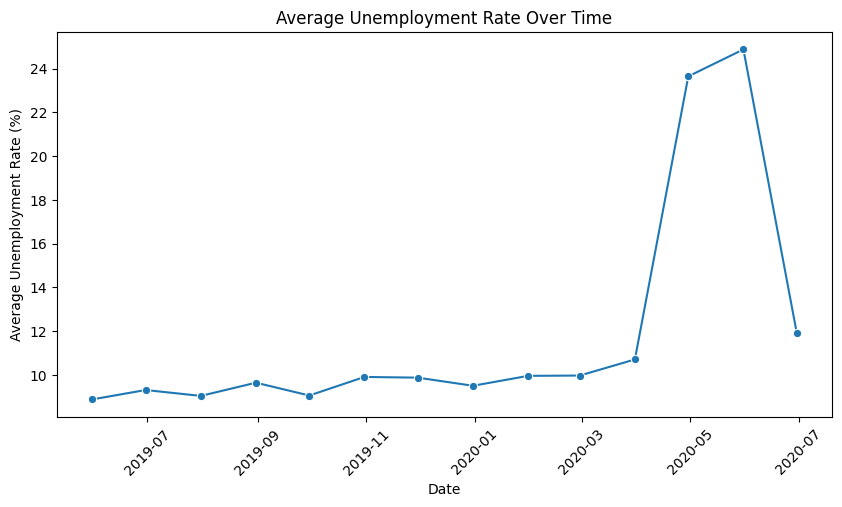

In [ ]:

monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_unemployment,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

# Insight

The line chart shows that the average unemployment rate varies over time rather than remaining constant. The unemployment rate remains relatively stable during some periods but shows a noticeable increase during a particular period, followed by a decline. This indicates that employment conditions changed considerably during the period covered by the dataset

## 3 Regional Analysis

### Average Unemployment Rate by Region

The average unemployment rate is calculated for each region and arranged
from highest to lowest to compare regional differences.

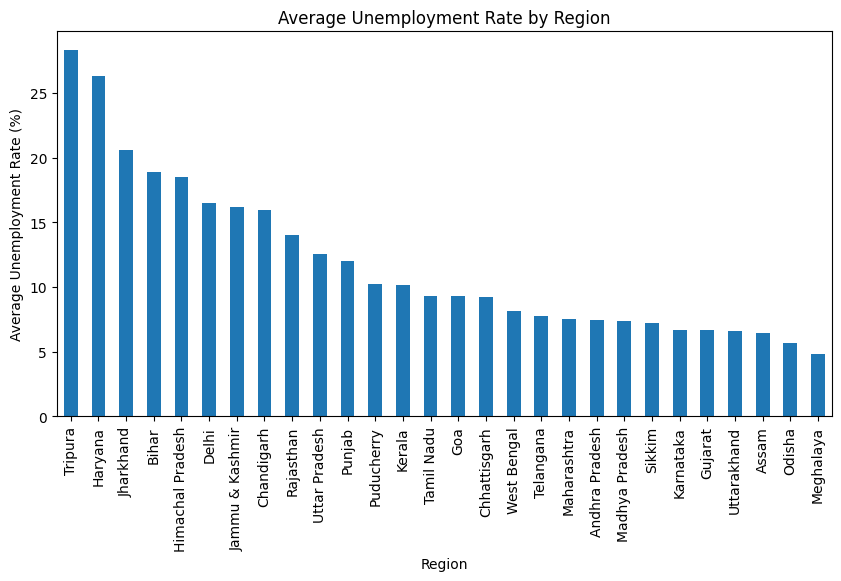

In [ ]:
region_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

region_unemployment
plt.figure(figsize=(10, 5))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.show()

### Insight

The regional comparison shows that unemployment rates vary considerably
across regions. Some regions have substantially higher average
unemployment than others, indicating differences in employment conditions.

## 4 Rural vs Urban Analysis

### Unemployment Rate by Area

A box plot is used to compare the distribution of unemployment rates
between Rural and Urban areas and identify potential outliers.

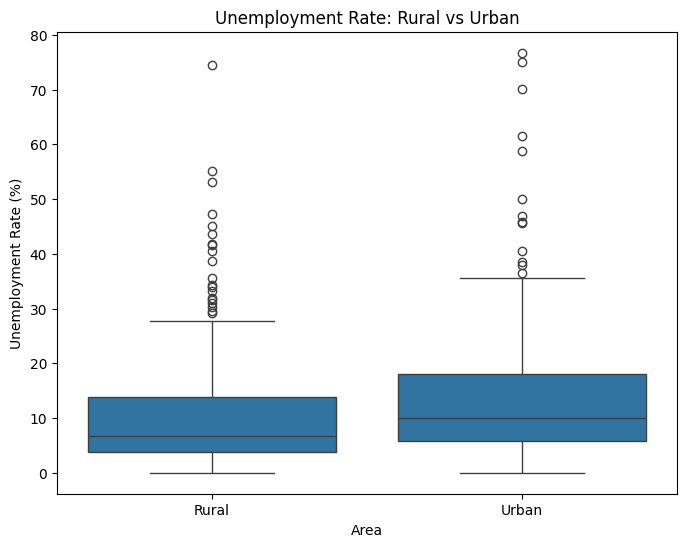

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.show()

# Insight

The box plot shows differences in the distribution of unemployment rates between Rural and Urban areas. The median and spread of unemployment rates provide an indication of how unemployment varies across the two areas. The presence of points outside the whiskers indicates potential outliers, representing observations with unusually high or low unemployment rates.

## 5 Bivariate Analysis

###  Unemployment Rate vs Labour Participation Rate

A scatter plot is used to investigate the relationship between unemployment
rate and labour participation rate. Each point represents an observation
in the dataset.

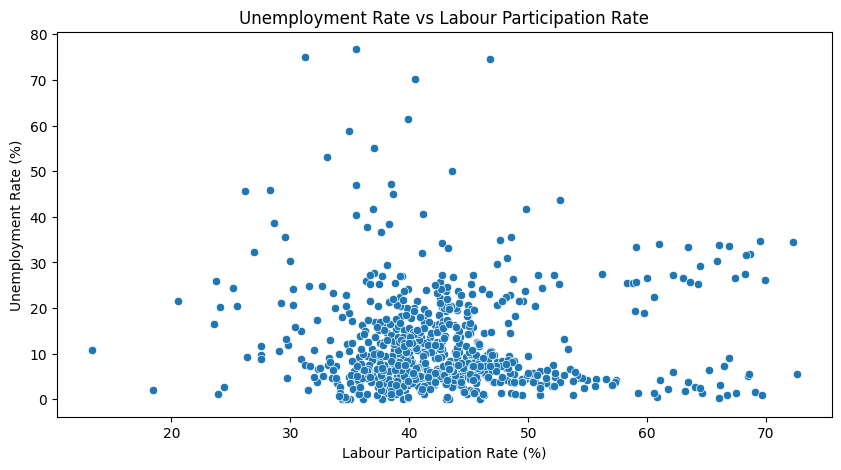

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate vs Labour Participation Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')

plt.show()

# Insight

The scatter plot shows the relationship between the estimated unemployment rate and labour participation rate. The points are widely distributed, suggesting that the relationship between the two variables is not perfectly strong. The plot also contains some observations that are relatively distant from the main concentration of points, which may represent potential bivariate outliers.

## 6 Correlation Analysis

###  Correlation Heatmap

The correlation heatmap is used to examine the strength and direction of
relationships between numerical variables in the dataset.

Correlation values range from -1 to +1. Values closer to +1 indicate a
positive relationship, while values closer to -1 indicate a negative
relationship.

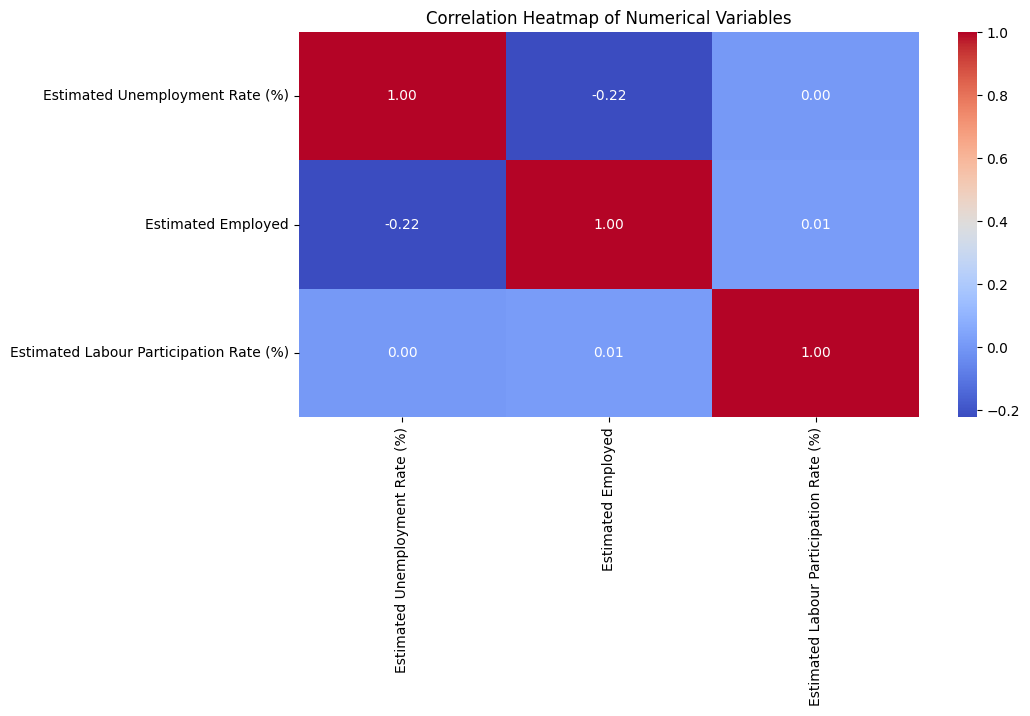

In [ ]:
correlation = df.corr(numeric_only=True)

correlation
plt.figure(figsize=(10, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

# Insight

The correlation heatmap provides an overview of the relationships between the numerical variables in the dataset. It helps identify variables that have relatively strong positive or negative relationships. The heatmap also shows whether unemployment rate, employment, and labour participation tend to move together.

#  Key Findings

Based on the exploratory analysis:

1. The unemployment rate shows substantial variation across observations.
2. The distribution of unemployment rates is positively skewed, with
   some unusually high observations.
3. Unemployment rates vary across different regions.
4. Rural and Urban areas show differences in the distribution of
   unemployment rates.
5. The scatter plot helps examine the relationship between unemployment
   and labour participation.
6. The correlation heatmap highlights relationships among the numerical
   variables.
7. Potential outliers were identified through graphical analysis and
   should be investigated before further statistical modelling.

#  Conclusion

The Exploratory Data Analysis provided an overall understanding of
unemployment patterns in India. The analysis examined the distribution
of unemployment rates, changes over time, regional differences,
Rural-Urban variation, relationships between numerical variables, and
potential outliers.

The visualizations and descriptive statistics helped identify important
patterns and provided a foundation for further analysis and
decision-making.